##Step 0. Environment Setup and Imports
This section imports tools from four core ecosystems:

Materials Science Libraries: mp_api is used to fetch real-world data directly from the Materials Project database; pymatgen is the library for handling crystal structures (lattice parameters, atomic coordinates).

Deep Learning Libraries: torch and torch.nn are used to build the foundational neural network components.

Graph Neural Network Libraries: torch_geometric (PyG) is the most mainstream GNN framework, used here for processing graph-structured data (e.g., MessagePassing, DataLoader).

Data Science & Visualization: pandas, numpy, and matplotlib are used for data manipulation and plotting.

In [ ]:
!pip install mp-api pymatgen torch_geometric tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 6.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.2/114.2 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.4/883.4 kB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 83.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.6/41.6 MB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 108.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 73.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch_geometric.nn import MessagePassing, global_mean_pool
from torch_geometric.data import Data, DataLoader
from torch.utils.data import Subset
from mp_api.client import MPRester
from pymatgen.core import Structure
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import seaborn as sns
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer

import random

##Step 1. Core Model Definition (CGCNN Architecture)

We replicated the architecture from the *Crystal Graph Convolutional Neural Networks for an Accurate and Interpretable Prediction of Material Properties* by Tian Xie and Jeffrey C. Grossman (2019).

GaussianSmearing:

Neural networks generally struggle to process raw scalar values directly (e.g., a bond distance of 2.5 Å). This class expands a single continuous distance value into a 40-dimensional feature vector using 40 Gaussian functions with different means. It allows the model to perceive spatial distances in a much smoother and richer feature space.

In [ ]:
class GaussianSmearing(nn.Module):
    def __init__(self, start=0.0, stop=8.0, num_gaussians=40):
        super().__init__()
        offset = torch.linspace(start, stop, num_gaussians)
        self.coeff = -0.5 / ((stop - start) / (num_gaussians - 1)) ** 2
        self.register_buffer('offset', offset)

    def forward(self, dist):
        dist = dist.view(-1, 1) - self.offset.view(1, -1)
        return torch.exp(self.coeff * torch.pow(dist, 2))

CGCNNConv (Graph Convolutional Layer):

It defines how atoms "communicate" or pass messages to each other. The code concatenates the center atom features (x_i), neighbor atom features (x_j), and the bond features (edge_attr) before passing them through a fully connected layer. chunk(2, dim=-1) splits the output in half. One half passes through a Sigmoid function to become a Gate (values 0~1), and the other half passes through a Softplus function to become the Message (Filter). Multiplying them allows the model to automatically learn "which interactions are strong and should pass more information, and which are weak and should be blocked."

In [ ]:

class CGCNNConv(MessagePassing):
    def __init__(self, node_dim, edge_dim):
        super().__init__(aggr='add')
        self.fc_full = nn.Linear(2 * node_dim + edge_dim, 2 * node_dim)
        self.bn1 = nn.BatchNorm1d(2 * node_dim)
        self.bn2 = nn.BatchNorm1d(node_dim)

    def forward(self, x, edge_index, edge_attr):
        return self.propagate(edge_index, x=x, edge_attr=edge_attr)

    def message(self, x_i, x_j, edge_attr):
        z = torch.cat([x_i, x_j, edge_attr], dim=-1)
        z = self.fc_full(z)
        z = self.bn1(z)
        gate, filter_ = z.chunk(2, dim=-1)
        return torch.sigmoid(gate) * F.softplus(filter_)

    def update(self, aggr_out, x):
        return F.softplus(x + self.bn2(aggr_out))

CGCNN_UQ:

Assembles the above components.Workflow: It first maps the 7-dimensional physical features into a 64D space (embedding) -> updates each atom's state through multiple graph convolution layers (convs) -> uses global_mean_pool to average the features of all atoms, yielding a representation for the entire crystal (this physically ensures that the predicted band gap is an intensive property, independent of supercell size)  -> finally passes through fully connected layers (fc_out) to predict the band gap.

In [ ]:
class CGCNN_UQ(nn.Module):
    def __init__(self, input_dim=7, node_dim=64, edge_dim=40, num_layers=3, dropout_p=0.2):
        super().__init__()
        self.embedding = nn.Linear(input_dim, node_dim)
        self.distance_expansion = GaussianSmearing(0, 8.0, edge_dim)
        self.convs = nn.ModuleList([CGCNNConv(node_dim, edge_dim) for _ in range(num_layers)])
        self.fc_out = nn.Sequential(
            nn.Linear(node_dim, 32),
            nn.Softplus(),
            nn.Dropout(p=dropout_p),
            nn.Linear(32, 1)
        )

    def forward(self, data):
        x, edge_index, edge_weight, batch = data.x, data.edge_index, data.edge_weight, data.batch
        x = self.embedding(x)
        edge_attr = self.distance_expansion(edge_weight)
        for conv in self.convs:
            x = conv(x, edge_index, edge_attr)
        x = global_mean_pool(x, batch)
        return self.fc_out(x).squeeze()

In [ ]:
class New_CGCNN_UQ(nn.Module):
    def __init__(self, node_dim=64, edge_dim=40, num_layers=3, dropout_p=0.2):
        super().__init__()
        self.z_embedding = nn.Embedding(num_embeddings=120, embedding_dim=32)
        self.continuous_proj = nn.Linear(6, 32)
        self.feature_fusion = nn.Sequential(
            nn.Linear(32 + 32, node_dim),
            nn.Softplus()
        )
        self.distance_expansion = GaussianSmearing(0, 8.0, edge_dim)

        self.convs = nn.ModuleList([CGCNNConv(node_dim, edge_dim) for _ in range(num_layers)])

        self.fc_out = nn.Sequential(
            nn.Linear(node_dim, 32),
            nn.Softplus(),
            nn.Dropout(p=dropout_p),
            nn.Linear(32, 1)
        )

    def forward(self, data):
        x, edge_index, edge_weight, batch = data.x, data.edge_index, data.edge_weight, data.batch
        z = x[:, 0].long()
        cont_features = x[:, 1:]

        z_emb = self.z_embedding(z)
        cont_emb = self.continuous_proj(cont_features)

        x_fused = torch.cat([z_emb, cont_emb], dim=-1)
        x_node = self.feature_fusion(x_fused)

        edge_attr = self.distance_expansion(edge_weight)

        for conv in self.convs:
            x_node = conv(x_node, edge_index, edge_attr)

        x_pooled = global_mean_pool(x_node, batch)
        return self.fc_out(x_pooled).squeeze()

## Step 2. Data Processing Tools (Data Preprocessing)
Neural networks are picky; crystal structures must be preprocessed into a format they can digest.

Normalizer (Target Normalization):

Calculates the mean and standard deviation of the band gaps in the training set. During training, it transforms the true band gaps into a distribution with a mean of 0 and a variance of 1 (norm). During prediction, it reverts the values back to the physical unit of eV (denorm).

In [ ]:
class Normalizer:
    def __init__(self, tensor):
        self.mean = torch.mean(tensor)
        self.std = torch.std(tensor)
    def norm(self, tensor): return (tensor - self.mean) / self.std
    def denorm(self, tensor): return tensor * self.std + self.mean

get_node_features (Physical/Chemical Prior Extraction):

Iterates through every atom in the crystal and extracts 7 human-engineered physical and chemical features (Atomic Number, Group, Period, Electronegativity, Covalent Radius, Mendeleev Number, Atomic Mass).

Instead of forcing the model to learn element properties from scratch, feeding it these "human prior knowledge" features (aligning with Table II of the paper) makes the model converge much faster and more accurately.

In [ ]:
def get_node_features(structure):
    feats = []
    for site in structure:
        e = site.specie
        feats.append([e.Z, e.group, e.row, e.X if e.X else 0,
                      e.atomic_radius if e.atomic_radius else 0, e.mendeleev_no, e.atomic_mass])
    return torch.tensor(feats, dtype=torch.float)

structure_to_pyg (Crystal-to-Graph Conversion):

Converts pymatgen Structure objects into PyG Data objects. It searches for neighbor atoms within a cutoff radius of 8.0 Å. The found connections become the edges (edge_index), and their physical distances become the edge weights (edge_weight).

In [ ]:
def structure_to_pyg(structure, target, cutoff=8.0):
    x = get_node_features(structure)
    all_nbrs = structure.get_all_neighbors(r=cutoff)
    src, dst, dist = [], [], []
    for i, nbrs in enumerate(all_nbrs):
        for n in nbrs:
            src.append(i); dst.append(n.index); dist.append(n.nn_distance)
    return Data(x=x, edge_index=torch.tensor([src, dst], dtype=torch.long),
                edge_weight=torch.tensor(dist, dtype=torch.float), y=torch.tensor([target], dtype=torch.float))


## Step 3. Execution
Runs the data through the model.

Data Download & Split:
Uses the API Key to fetch typical, stable semiconductor materials (band gap between 0.5 - 4.0 eV) from the Materials Project. It takes the first 500 structures and splits them 80/20 into training and validation sets.


Training Loop:

Sets model.train() for normal forward propagation.

Calculates the Mean Squared Error (MSE Loss) between the predictions and the normalized true targets.

Performs backpropagation to update network weights (optimizer.step()) over 50 epochs.

Monte Carlo Dropout Inference (MC Dropout UQ):
Normally, model.eval() disables Dropout during testing. However, the code follows it with a loop: if isinstance(m, nn.Dropout): m.train(). This forces the network to keep 20% of its neurons randomly deactivated during testing.

Sampling: For the same material, the network predicts 50 times (simulating an ensemble of 50 slightly different models).

Statistics: It calculates the mean of these 50 predictions (used as the final predicted band gap, all_means) and the standard deviation (used as the model's confidence index / Uncertainty, all_stds).

In [ ]:
API_KEY = "EEruUTWCYPbkR2GcP3fbGy70F9nfD4eK"

with MPRester(API_KEY) as mpr:
    print("Downloading from Materials Project...")
    docs = mpr.summary.search(band_gap=(0.5, 4.0), is_stable=True,
                              fields=["structure", "band_gap", "material_id"])

    print(f"Total documents retrieved: {len(docs)}")
    dataset = [structure_to_pyg(d.structure, d.band_gap) for d in docs]

/tmp/ipykernel_3835/2332343468.py:5: DeprecationWarning: Accessing summary data through MPRester.summary is deprecated. Please use MPRester.materials.summary instead.
  docs = mpr.summary.search(band_gap=(0.5, 4.0), is_stable=True,


Retrieving SummaryDoc documents:   0%|          | 0/12028 [00:00<?, ?it/s]

Total documents retrieved: 12028


100%|██████████| 12028/12028 [00:36<00:00, 328.09it/s]


Successfully extracted statistics for 12028 materials. Plotting distributions...


/tmp/ipykernel_3835/3805956737.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=crystal_counts.index, y=crystal_counts.values, palette="viridis", ax=axes[0, 1])


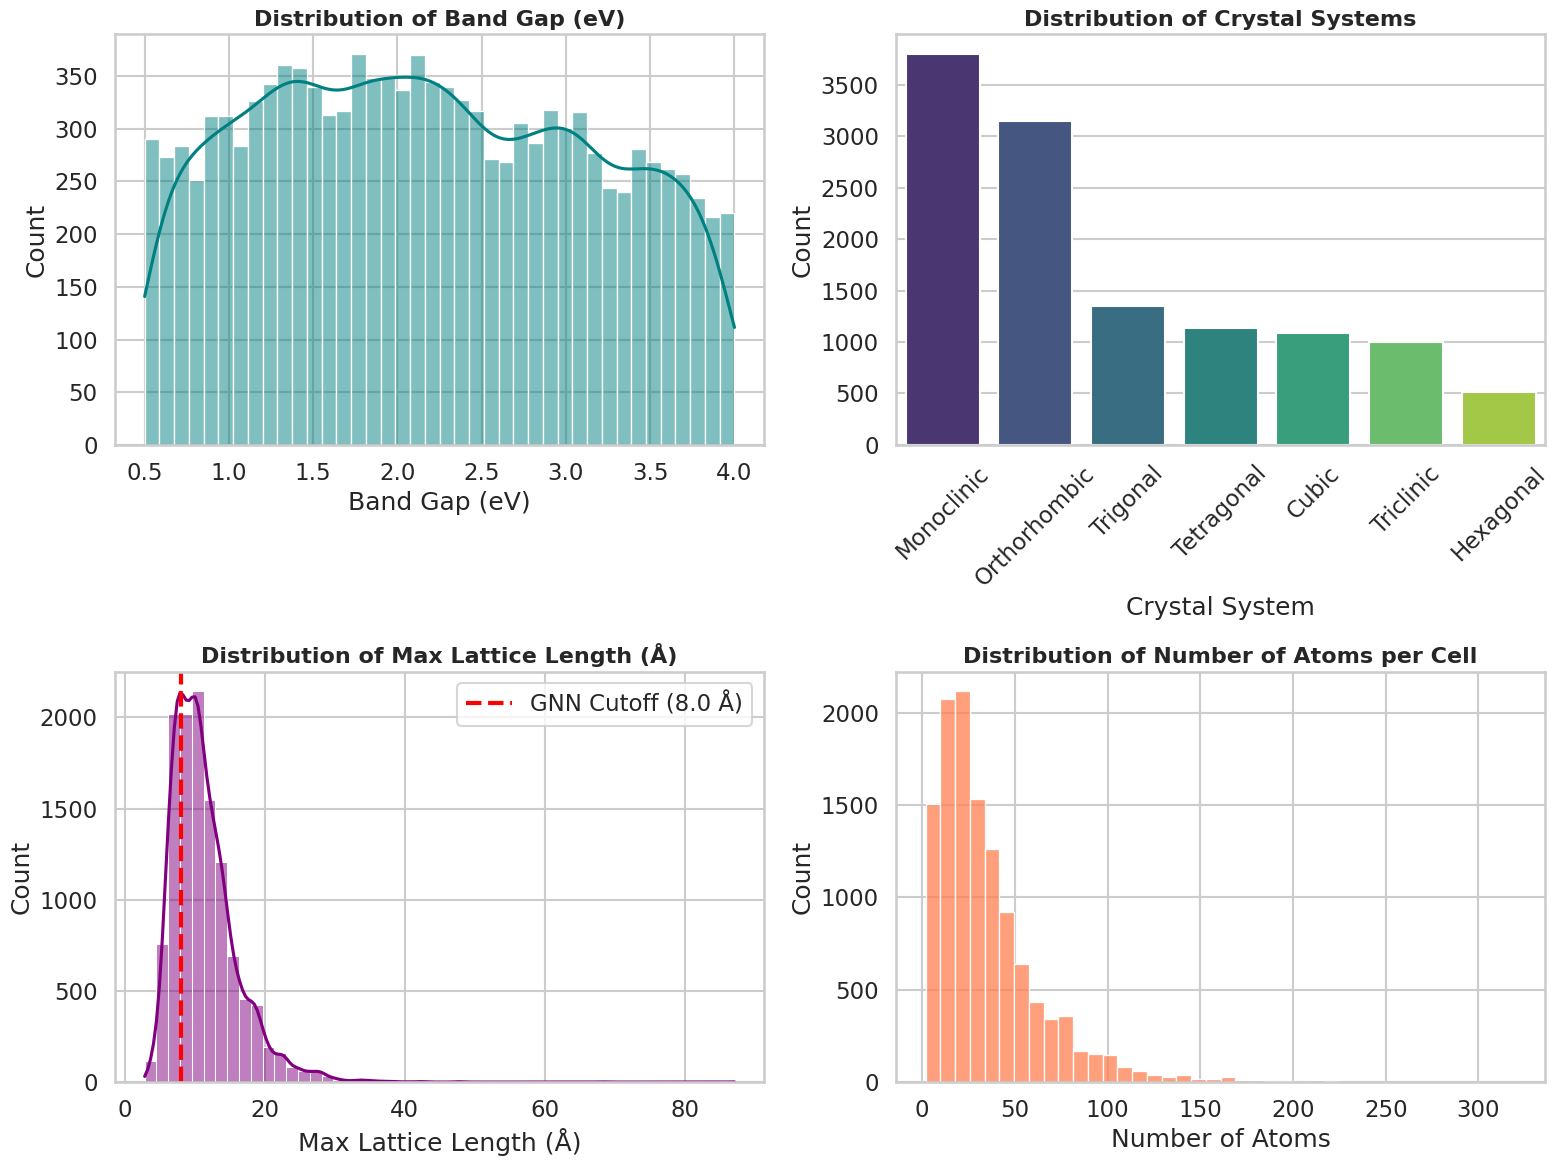

In [ ]:
# 1. Extract the physical features we need for statistical analysis from the docs
data_records = []
for d in tqdm(docs):
    struct = d.structure
    lattice = struct.lattice

    # Use SpacegroupAnalyzer to obtain the crystal system
    try:
        sga = SpacegroupAnalyzer(struct)
        crystal_system = sga.get_crystal_system()
    except:
        crystal_system = "Unknown"

    data_records.append({
        "Band_Gap": d.band_gap,
        "Max_Lattice": max(lattice.a, lattice.b, lattice.c),
        "Num_Atoms": struct.num_sites,
        "Crystal_System": crystal_system.capitalize() if crystal_system else "Unknown"
    })

# Convert to a Pandas DataFrame for easier analysis and visualization
df_stats = pd.DataFrame(data_records)

print(f"Successfully extracted statistics for {len(df_stats)} materials. Plotting distributions...")

# ==========================================
# 2. Use Seaborn to plot a 2x2 panel of statistical charts
# ==========================================

# Set plotting style
sns.set_theme(style="whitegrid", context="talk")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Band gap distribution ---
sns.histplot(df_stats['Band_Gap'], bins=40, kde=True, color="teal", ax=axes[0, 0])
axes[0, 0].set_title("Distribution of Band Gap (eV)", fontsize=16, fontweight='bold')
axes[0, 0].set_xlabel("Band Gap (eV)")
axes[0, 0].set_ylabel("Count")

# Plot 2: Crystal system distribution (bar chart) ---
# Count frequency of each crystal system and sort in descending order
crystal_counts = df_stats['Crystal_System'].value_counts()
sns.barplot(x=crystal_counts.index, y=crystal_counts.values, palette="viridis", ax=axes[0, 1])
axes[0, 1].set_title("Distribution of Crystal Systems", fontsize=16, fontweight='bold')
axes[0, 1].set_xlabel("Crystal System")
axes[0, 1].set_ylabel("Count")
axes[0, 1].tick_params(axis='x', rotation=45)

# Plot 3: Distribution of maximum lattice length
sns.histplot(df_stats['Max_Lattice'], bins=50, kde=True, color="purple", ax=axes[1, 0])
axes[1, 0].set_title("Distribution of Max Lattice Length (Å)", fontsize=16, fontweight='bold')
axes[1, 0].set_xlabel("Max Lattice Length (Å)")
axes[1, 0].set_ylabel("Count")
# Draw a red line indicating the GNN cutoff radius
axes[1, 0].axvline(x=8.0, color='red', linestyle='--', linewidth=3, label='GNN Cutoff (8.0 Å)')
axes[1, 0].legend()

# Plot 4: Distribution of number of atoms per unit cell ---
sns.histplot(df_stats['Num_Atoms'], bins=40, kde=False, color="coral", ax=axes[1, 1])
axes[1, 1].set_title("Distribution of Number of Atoms per Cell", fontsize=16, fontweight='bold')
axes[1, 1].set_xlabel("Number of Atoms")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [ ]:
train_pool_idx, val_idx = train_test_split(
    range(len(dataset)),
    test_size=1000,
    random_state=42
)

CURRENT_TRAIN_SIZE = 11000
random.seed(42)
if CURRENT_TRAIN_SIZE > len(train_pool_idx):
    train_idx = train_pool_idx
else:
    train_idx = random.sample(train_pool_idx, CURRENT_TRAIN_SIZE)

# Constructing DataLoaders and Normalizing Target Values
# Extract the actual graph data from the original dataset based on the sampled indices.
train_loader = DataLoader([dataset[i] for i in train_idx], batch_size=32, shuffle=True)
val_loader = DataLoader([dataset[i] for i in val_idx], batch_size=32)

train_y = torch.tensor([dataset[i].y.item() for i in train_idx])
normalizer = Normalizer(train_y)

# Model and optimizer initialization
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = New_CGCNN_UQ().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
optimizer, mode='min', factor=0.5, patience=10
)

epochs = 200
train_losses = []
val_losses = []
print(f"\nStart Training {model.__class__.__name__}...")

for epoch in range(epochs):
    model.train()
    epoch_train_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()

        output = model(data)
        target_norm = normalizer.norm(data.y)

        loss = F.mse_loss(output, target_norm)
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item() * data.num_graphs

    epoch_train_loss /= len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for data in val_loader:
            data = data.to(device)
            output = model(data)
            target_norm = normalizer.norm(data.y)

            val_loss = F.mse_loss(output, target_norm)
            epoch_val_loss += val_loss.item() * data.num_graphs

    epoch_val_loss /= len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    scheduler.step(epoch_val_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:03d}/{epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | LR: {current_lr:.6f}")

/tmp/ipykernel_3835/241101051.py:16: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader = DataLoader([dataset[i] for i in train_idx], batch_size=32, shuffle=True)
/tmp/ipykernel_3835/241101051.py:17: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  val_loader = DataLoader([dataset[i] for i in val_idx], batch_size=32)



Start Training New_CGCNN_UQ...
Epoch 001/200 | Train Loss: 0.7306 | Val Loss: 0.6053 | LR: 0.001000
Epoch 010/200 | Train Loss: 0.4725 | Val Loss: 0.5368 | LR: 0.001000
Epoch 020/200 | Train Loss: 0.3970 | Val Loss: 0.3547 | LR: 0.001000
Epoch 030/200 | Train Loss: 0.3446 | Val Loss: 0.4523 | LR: 0.001000
Epoch 040/200 | Train Loss: 0.3065 | Val Loss: 0.2798 | LR: 0.001000
Epoch 050/200 | Train Loss: 0.2805 | Val Loss: 0.2608 | LR: 0.001000
Epoch 060/200 | Train Loss: 0.2601 | Val Loss: 0.2798 | LR: 0.001000
Epoch 070/200 | Train Loss: 0.2405 | Val Loss: 0.2409 | LR: 0.001000
Epoch 080/200 | Train Loss: 0.2312 | Val Loss: 0.2246 | LR: 0.001000
Epoch 090/200 | Train Loss: 0.2277 | Val Loss: 0.2251 | LR: 0.001000
Epoch 100/200 | Train Loss: 0.1880 | Val Loss: 0.2397 | LR: 0.000500
Epoch 110/200 | Train Loss: 0.1812 | Val Loss: 0.2217 | LR: 0.000500
Epoch 120/200 | Train Loss: 0.1771 | Val Loss: 0.2121 | LR: 0.000500
Epoch 130/200 | Train Loss: 0.1566 | Val Loss: 0.2068 | LR: 0.000250
Ep

Result Visualization:

Uses plt.errorbar to plot a parity plot comparing true vs. predicted band gaps.

The yerr=all_stds argument draws red error bars vertically. A longer error bar means the 50 predictions varied wildly, indicating the model is "highly unconfident" about that specific crystal structure. Based on Sheng Gong's paper, these high-uncertainty points are often materials with large unit cells or periodicities that exceed the model's receptive field.

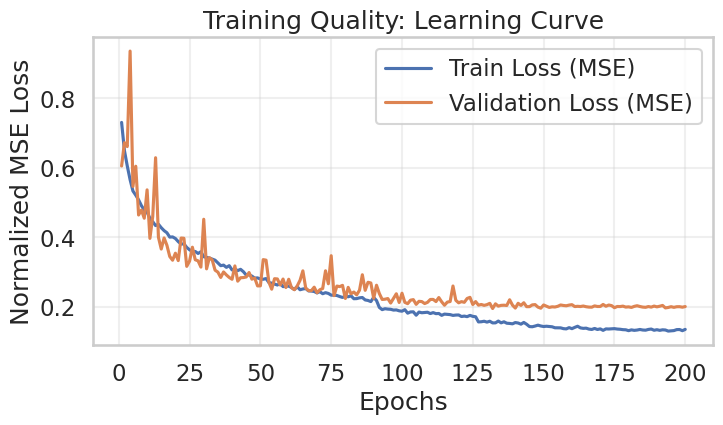

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs+1), train_losses, label='Train Loss (MSE)')
plt.plot(range(1, epochs+1), val_losses, label='Validation Loss (MSE)')
plt.xlabel('Epochs')
plt.ylabel('Normalized MSE Loss')
plt.title('Training Quality: Learning Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Start the Monte Carlo Dropout Evaluation...

--- Validation Set ---
Mean Absolute Error (MAE): 0.3187 eV
Root Mean Square Error (RMSE):  0.4341 eV
R-squared: 0.7961


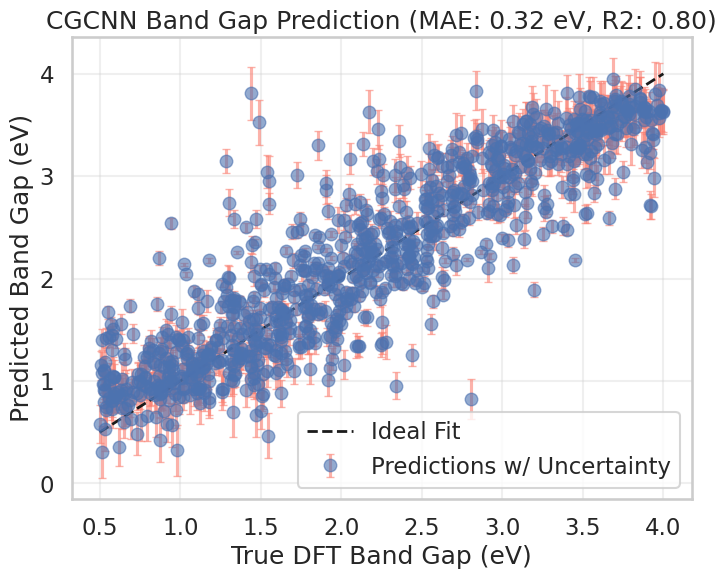

In [ ]:
print("\nStart the Monte Carlo Dropout Evaluation...")
model.eval()
for m in model.modules():
    if isinstance(m, nn.Dropout): m.train()

all_means, all_stds, all_trues = [], [], []
with torch.no_grad():
    for data in val_loader:
        data = data.to(device)
        preds = torch.stack([normalizer.denorm(model(data)) for _ in range(50)])
        all_means.extend(preds.mean(0).cpu().numpy())
        all_stds.extend(preds.std(0).cpu().numpy())
        all_trues.extend(data.y.cpu().numpy())

mae = mean_absolute_error(all_trues, all_means)
rmse = np.sqrt(mean_squared_error(all_trues, all_means))
r2 = r2_score(all_trues, all_means)

print("\n--- Validation Set ---")
print(f"Mean Absolute Error (MAE): {mae:.4f} eV")
print(f"Root Mean Square Error (RMSE):  {rmse:.4f} eV")
print(f"R-squared: {r2:.4f}")

plt.figure(figsize=(8, 6))
plt.errorbar(all_trues, all_means, yerr=all_stds, fmt='o', alpha=0.6, ecolor='salmon', capsize=3, label='Predictions w/ Uncertainty')
plt.plot([0.5, 4], [0.5, 4], 'k--', linewidth=2, label='Ideal Fit')
plt.xlabel("True DFT Band Gap (eV)")
plt.ylabel("Predicted Band Gap (eV)")
plt.title(f"CGCNN Band Gap Prediction (MAE: {mae:.2f} eV, R2: {r2:.2f})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()